In [1]:
import pickle, gzip
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
import re
import os

In [3]:
def save_figure(fig, figname, outdir=''):
    outname=os.path.join(outdir, f"{figname}.png")
    fig.savefig(outname, bbox_inches='tight', format='png')
    print(f'plot saved to {outname}')
    plt.close(fig)

def get_shape_syst_lst(base_histo, ignore_list=[]):
    # Get unique systematic base names (e.g., "ISR" from "ISRUp")
    all_syst_var_lst = list(base_histo.axes["systematic"])
    syst_var_lst = []
    for name in all_syst_var_lst:
        if name.endswith("Up"):
            base_name = name[:-2] # strip "Up" to get the base systematic name
            if base_name in ignore_list: continue
            if base_name not in syst_var_lst:
                syst_var_lst.append(base_name)
                
    return syst_var_lst

year_naming = {
    "2016APV": "UL16APV",
    "2016": "UL16",
    "2017": "UL17",
    "2018": "UL18",
}

# def get_syst_year_tag(syst_name, year_naming):

#     sorted_years = sorted(
#         year_naming.keys(),
#         key=len,
#         reverse=True
#     )
#     for year in sorted_years:
#         if year in syst_name:
#             return year_naming[year]
#     return None

# def is_year_specifc(syst_name):
#     if ('16' in syst_name) or ('17' in syst_name) or ('18' in syst_name)
#         return True 
#     else: return False

def get_syst_year(syst_name):
    for syst_year in year_naming:
        if syst_year in syst_name:
            return syst_year
    return None


def get_proc_year(proc_name):
    for syst_year, proc_year in year_naming.items():
        if proc_name.endswith(proc_year):
            return syst_year
    return None


def get_shape_syst_arrs(base_histo, syst_var_lst, PDF_var_histo=None):
    # Mapping between systematic name years and process axis year tags
    year_naming = {
        "2016APV": "UL16APV",
        "2016": "UL16",
        "2017": "UL17",
        "2018": "UL18",
    }

    p_arr_rel_lst = []
    m_arr_rel_lst = []

    for syst_name in syst_var_lst:
        if syst_name in ["renormfact", "LHEPDFweight"]:
            continue

        # --- PDF Uncertainty Handling ---
        if syst_name == "PDF" and PDF_var_histo:
            print("running PDF uncertainties")
            relevant_samples_lst = list(PDF_var_histo.axes["process"])
            h = PDF_var_histo[{"process": relevant_samples_lst}]

            nominal = h[{'PDFindex': 0}].values()
            variations = h[{"PDFindex": slice(1, None)}].values()

            diff_sq = np.square(variations - nominal[..., np.newaxis])
            sigma_pdf = np.sqrt(np.sum(diff_sq, axis=-1))

            total_sigma_pdf = np.sum(sigma_pdf, axis=0)

            # PDF uncertainties are symmetric; append directly to quadrature lists
            p_arr_rel_lst.append(total_sigma_pdf**2)
            m_arr_rel_lst.append(total_sigma_pdf**2)
            continue
            
        elif syst_name == "PDF": 
            print("NOT running PDF uncertainties")
            continue

        # --- Standard & Year-Specific Systematic Handling ---
        
        # Determine if this systematic is tied to a specific year
        syst_year_suffix = None
        target_process_year = None
        for yr_syst, yr_proc in year_naming.items():
            if yr_syst in syst_name:
                syst_year_suffix = yr_syst
                target_process_year = yr_proc
                break

        # Identify all relevant samples that have this systematic variation
        h_up = base_histo[{"systematic": syst_name + "Up"}]
        all_relevant_samples = list(h_up.axes["process"])

#         if syst_year_suffix:
            
#             # Separate samples: those matching the systematic's year vs all other years
#             exact_target = f"_{target_process_year}"

#             if target_process_year == "UL16":
#                 # Grab anything containing _UL16 but NOT _UL16APV
#                 var_samples = [s for s in all_relevant_samples if exact_target in s and "UL16APV" not in s]
#             else:
#                 # Standard matching for _UL16APV, _UL17, _UL18
#                 var_samples = [s for s in all_relevant_samples if exact_target in s]
                
        if syst_year_suffix:
            # 1. Target exactly what should vary
            if target_process_year == "UL16":
                # For 2016, look for UL16 but explicitly ignore UL16APV
                var_samples = [s for s in all_relevant_samples if "UL16" in s and "UL16APV" not in s]
            else:
                # For 2016APV, 2017, 2018, standard substring match works flawlessly
                var_samples = [s for s in all_relevant_samples if target_process_year in s]
            
            # 2. CRITICAL FIX: Set subtraction guarantees NO dropped samples.
            # Anything that isn't varying MUST be kept as nominal.
            nom_samples = [s for s in all_relevant_samples if s not in var_samples]

            # var_samples = [s for s in all_relevant_samples if target_process_year in s]
            # nom_samples = [s for s in all_relevant_samples if target_process_year not in s]

            # 1. Total Nominal (all relevant samples across all years)
            n_arr = base_histo[{"process": all_relevant_samples, "systematic": "nominal"}]
            n_arr = n_arr[{"process": sum}].values()

            # 2. Calculate Up Variation: (Target Year Up) + (Other Years Nominal)
            u_arr_var_year = base_histo[{"process": var_samples, "systematic": syst_name + "Up"}][{"process": sum}].values()
            u_arr_nom_years = base_histo[{"process": nom_samples, "systematic": "nominal"}][{"process": sum}].values() if nom_samples else 0
            u_arr_sum = u_arr_var_year + u_arr_nom_years

            # 3. Calculate Down Variation: (Target Year Down) + (Other Years Nominal)
            d_arr_var_year = base_histo[{"process": var_samples, "systematic": syst_name + "Down"}][{"process": sum}].values()
            d_arr_nom_years = base_histo[{"process": nom_samples, "systematic": "nominal"}][{"process": sum}].values() if nom_samples else 0
            d_arr_sum = d_arr_var_year + d_arr_nom_years

        else:
            # Standard treatment for year-correlated / full Run-2 systematics
            n_arr = base_histo[{"process": all_relevant_samples, "systematic": "nominal"}][{"process": sum}].values()
            u_arr_sum = base_histo[{"process": all_relevant_samples, "systematic": syst_name + "Up"}][{"process": sum}].values()
            d_arr_sum = base_histo[{"process": all_relevant_samples, "systematic": syst_name + "Down"}][{"process": sum}].values()

        # Differences relative to nominal
        u_arr_rel = u_arr_sum - n_arr
        d_arr_rel = d_arr_sum - n_arr
        
        # Envelope: Extract strictly positive and negative shifts relative to 0
        p_arr_rel = np.maximum.reduce([u_arr_rel, d_arr_rel, np.zeros_like(n_arr)])
        m_arr_rel = np.minimum.reduce([u_arr_rel, d_arr_rel, np.zeros_like(n_arr)])
        
#         if syst_year_suffix:  # Change to your target systematic
#             TARGET_BIN = 2  # Change to the bin index that doubles in uncertainty
            
#             print(f"\n" + "="*50)
#             print(f"DEBUGGING SYSTEMATIC: {syst_name} | Bin Index: {TARGET_BIN}")
#             print(f"ALL PROCS: {all_relevant_samples}")
#             print(f"="*50)
#             if syst_year_suffix:
#                 print(f"-> Year-specific mode activated ({syst_year_suffix} -> {target_process_year})")
#                 print(f"-> Varying samples: {var_samples}")
#                 print(f"-> Keeping nominal: {nom_samples}")
#             else:
#                 print(f"-> Full Run-2 / Inclusive mode activated")
#                 print(f"-> Samples included: {all_relevant_samples}")
                
#             print(f"\nRaw Yields for Bin {TARGET_BIN}:")
#             print(f"  Nominal Sum (n_arr) : {n_arr[TARGET_BIN]:.2f}")
#             print(f"  Up Sum (u_arr_sum)  : {u_arr_sum[TARGET_BIN]:.2f}")
#             print(f"  Down Sum (d_arr_sum): {d_arr_sum[TARGET_BIN]:.2f}")
            
#             print(f"\nRelative Shifts (Variation - Nominal):")
#             print(f"  Up Shift (u_arr_rel): {u_arr_rel[TARGET_BIN]:+.2f} ({(u_arr_rel[TARGET_BIN]/n_arr[TARGET_BIN])*100:+.1f}%)")
#             print(f"  Dn Shift (d_arr_rel): {d_arr_rel[TARGET_BIN]:+.2f} ({(d_arr_rel[TARGET_BIN]/n_arr[TARGET_BIN])*100:+.1f}%)")
            
#             print(f"\nEnvelope Results (Post-Reduction):")
#             print(f"  Positive Max (p_arr_rel): {p_arr_rel[TARGET_BIN]:.2f}")
#             print(f"  Negative Min (m_arr_rel): {m_arr_rel[TARGET_BIN]:.2f}")
#             print(f"="*50 + "\n")
            
        # p_arr_rel = np.where(u_arr_rel > 0, u_arr_rel, d_arr_rel)
        # m_arr_rel = np.where(u_arr_rel < 0, u_arr_rel, d_arr_rel)

        # Add in quadrature
        p_arr_rel_lst.append(p_arr_rel**2)
        m_arr_rel_lst.append(m_arr_rel**2)

    return [np.sum(m_arr_rel_lst, axis=0), np.sum(p_arr_rel_lst, axis=0)]

def get_shape_syst_arrs_noyears(base_histo, syst_var_lst, PDF_var_histo=None):
    # Get unique systematic base names (e.g., "ISR" from "ISRUp")
    p_arr_rel_lst = []
    m_arr_rel_lst = []

    for syst_name in syst_var_lst:
        # print(f"getting shape syst arr for {syst_name}")
        if syst_name == "renormfact": 
            continue
        if syst_name == "LHEPDFweight":
            continue

        if syst_name == "PDF" and PDF_var_histo:
            print(f"running PDF uncertainties")
            relevant_samples_lst = list(PDF_var_histo.axes["process"])
            h = PDF_var_histo[{"process":relevant_samples_lst}]

            nominal = h[{'PDFindex':0}].values()
            variations = h[{"PDFindex": slice(1, None)}].values()

            diff_sq = np.square(variations - nominal[..., np.newaxis])
            sigma_pdf = np.sqrt(np.sum(diff_sq, axis=-1))

            n_arr = np.sum(nominal, axis=0)
            total_sigma_pdf = np.sum(sigma_pdf, axis=0)

            p_arr_rel_lst.append(total_sigma_pdf**2)
            m_arr_rel_lst.append(total_sigma_pdf**2)
            continue
            
        elif syst_name == "PDF": 
            print(f"NOT running PDF uncertainties")
            continue

        if ('2016' in syst_name) or ('2017' in syst_name) or ('2018' in syst_name): 
            continue

        # Identify relevant samples for this systematic
        h_up = base_histo[{"systematic": syst_name + "Up"}]         # select the "Up" variation syst axis
        relevant_samples_lst = list(h_up.axes["process"])           # get the list of processes that have this syst var

        # Calculate Nominal (n_arr)
        n_arr = base_histo[{"process": relevant_samples_lst, "systematic": "nominal"}]      # select the 'nominal' systematic axis
        n_arr = n_arr[{"process": sum}].values()                                            # sum over the relevant processes

        # Calculate Up/Down variations
        u_arr_sum = base_histo[{"process": relevant_samples_lst, "systematic": syst_name + "Up"}]   # select the samples with an Up variation and the right axis
        u_arr_sum = u_arr_sum[{"process": sum}].values()                                            # sum over all relevant samples 
        
        d_arr_sum = base_histo[{"process": relevant_samples_lst, "systematic": syst_name + "Down"}]
        d_arr_sum = d_arr_sum[{"process": sum}].values()

        # Diff with respect to nominal
        u_arr_rel = u_arr_sum - n_arr
        d_arr_rel = d_arr_sum - n_arr
        
        # Just the ones that increase the yield
        p_arr_rel = np.where(u_arr_rel > 0, u_arr_rel, d_arr_rel)
        m_arr_rel = np.where(u_arr_rel < 0, u_arr_rel, d_arr_rel)

        # Add in quadrature
        p_arr_rel_lst.append(p_arr_rel**2)
        m_arr_rel_lst.append(m_arr_rel**2)

    return [np.sum(m_arr_rel_lst, axis=0), np.sum(p_arr_rel_lst, axis=0)]

In [3]:
# hists_dict = pickle.load(gzip.open("SR_ALL_260510.pkl.gz"))

hists_dict.keys()

dict_keys(['ee', 'mm', 'em'])

In [20]:
hists_powheg = pickle.load(gzip.open("SR_ALL_Powheg.pkl.gz"))

In [29]:
var = 'mllbb'
for d in hists_dict.keys():
    base_hist = hists_dict[d][var]
    MC_procs = [x for x in list(base_hist.axes['process']) if 'data' not in x]
    data_procs = [x for x in list(base_hist.axes['process']) if 'data' in x]
    
    powheg_MC_procs = [x for x in list(hists_powheg[d][var].axes['process']) if 'data' not in x]
    channels = list(base_hist.axes['channel'])

    for ch in channels: 
        MC_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':MC_procs}][{'process':sum}].as_hist({})
        Powheg_hist = hists_powheg[d][var][{'systematic':'nominal', 'channel':ch, 'process':powheg_MC_procs}][{'process':sum}].as_hist({})
        data_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':data_procs}][{'process':sum}].as_hist({})

        mc_err = base_hist[{'systematic':'sumw2', 'channel':ch, 'process':MC_procs}][{'process': sum}].as_hist({}).values()

        syst_to_apply = get_shape_syst_lst(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}))
        h_PDFweights = hists_dict[d]['LHEPDFweights'][{'channel':ch}]
        shape_systs_summed_arr_m , shape_systs_summed_arr_p = get_shape_syst_arrs(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}), syst_var_lst=syst_to_apply, PDF_var_histo=h_PDFweights)

        nom_arr_all = MC_hist.values() 
        p_err_arr = nom_arr_all + np.sqrt(shape_systs_summed_arr_p + mc_err)
        m_err_arr = nom_arr_all - np.sqrt(shape_systs_summed_arr_m + mc_err)

        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.style.use("CMS")

        hep.histplot(
            MC_hist,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            Powheg_hist,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )

        ## Data Plot
        # ax.set_xlim([0, 350])
        hep.histplot(
            data_hist[0:5], 
            histtype='errorbar',
            markersize=12,
            yerr=True,
            color='black',
            label='Data',
            ax=ax
        )

        mc_vals = MC_hist.values()
        bin_edges = np.asarray(MC_hist.axes.edges[0])
        bin_centers = MC_hist.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        # print(f"p_err/nom: {p_err_arr/mc_vals}")
        # print(f"m_err/nom: {m_err_arr/mc_vals}")

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.5, 1.0, 1.5])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        # plt.show()
        
        save_figure(fig, f"mllbb_{ch}_EFTvsPowheg", "/users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/")
        plt.close()

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


plot saved to /users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/mllbb_ee_2b_2j_EFTvsPowheg.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


plot saved to /users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/mllbb_ee_2b_3j_EFTvsPowheg.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


...

plot saved to /users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/mllbb_em_2b_2j_EFTvsPowheg.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


plot saved to /users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/mllbb_em_2b_3j_EFTvsPowheg.png


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


plot saved to /users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots/mllbb_em_2b_4j_EFTvsPowheg.png


In [2]:
hists_EFT = pickle.load(gzip.open("SR_ALL_2j3j_260519.pkl.gz"))
hists_powheg = pickle.load(gzip.open("SR_ALL_Powheg.pkl.gz"))

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


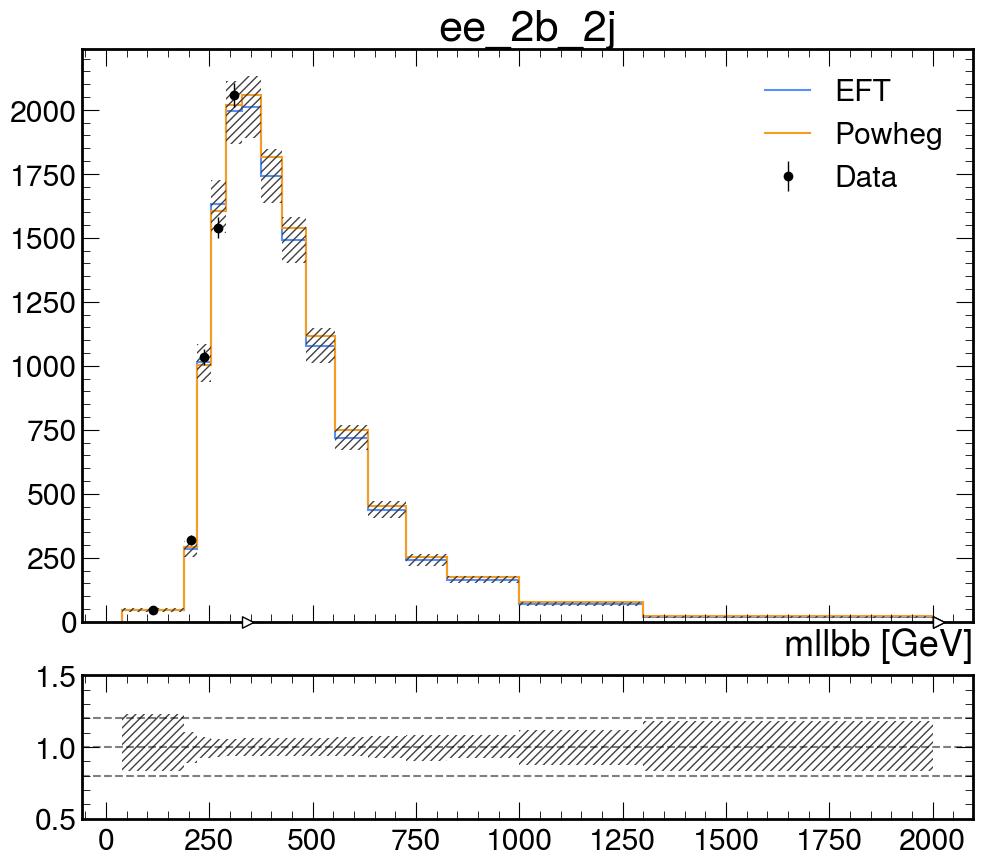

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


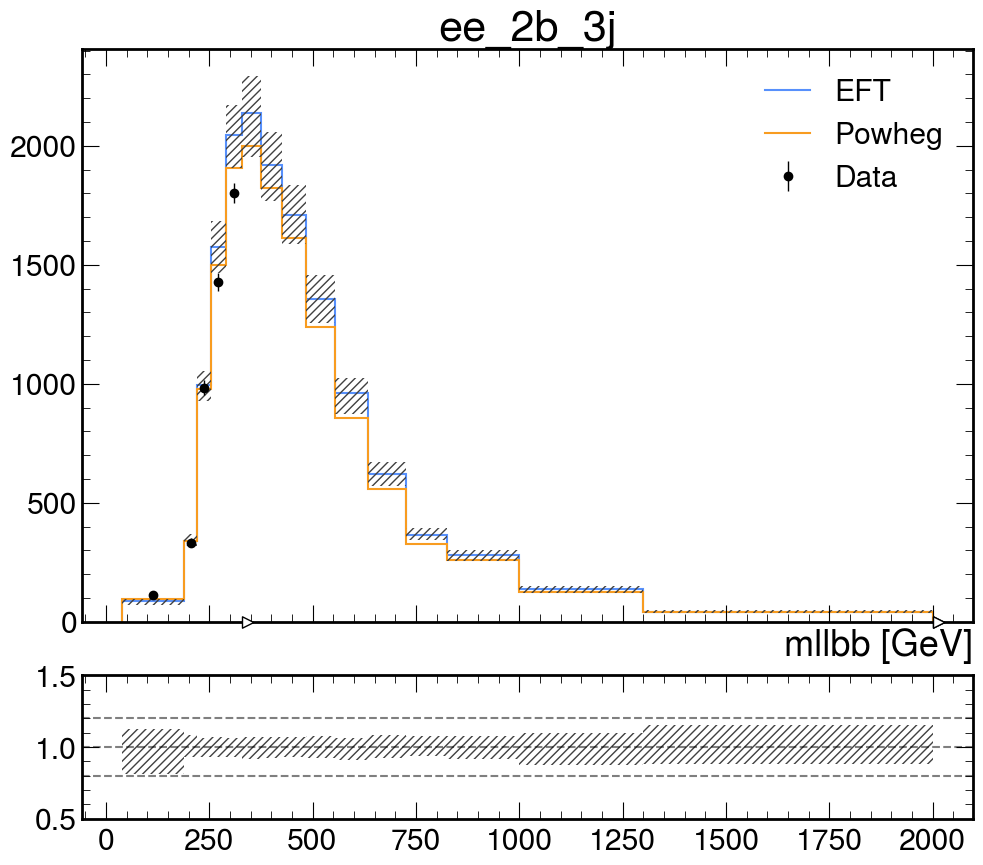

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


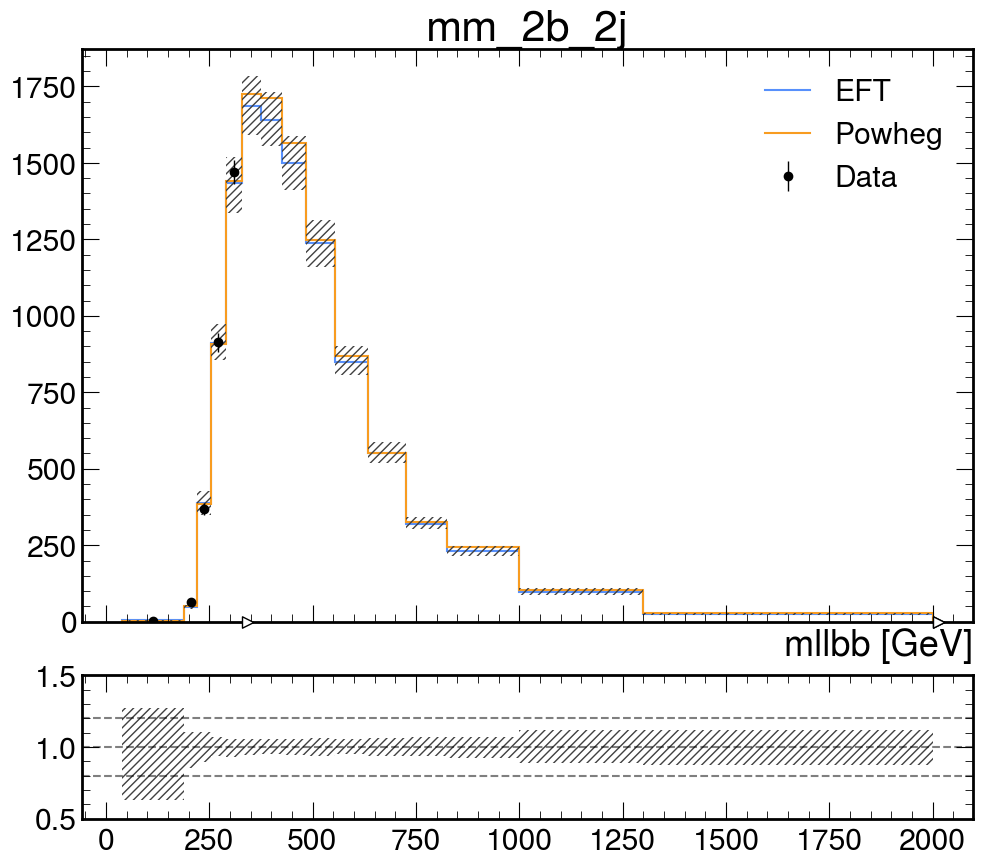

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


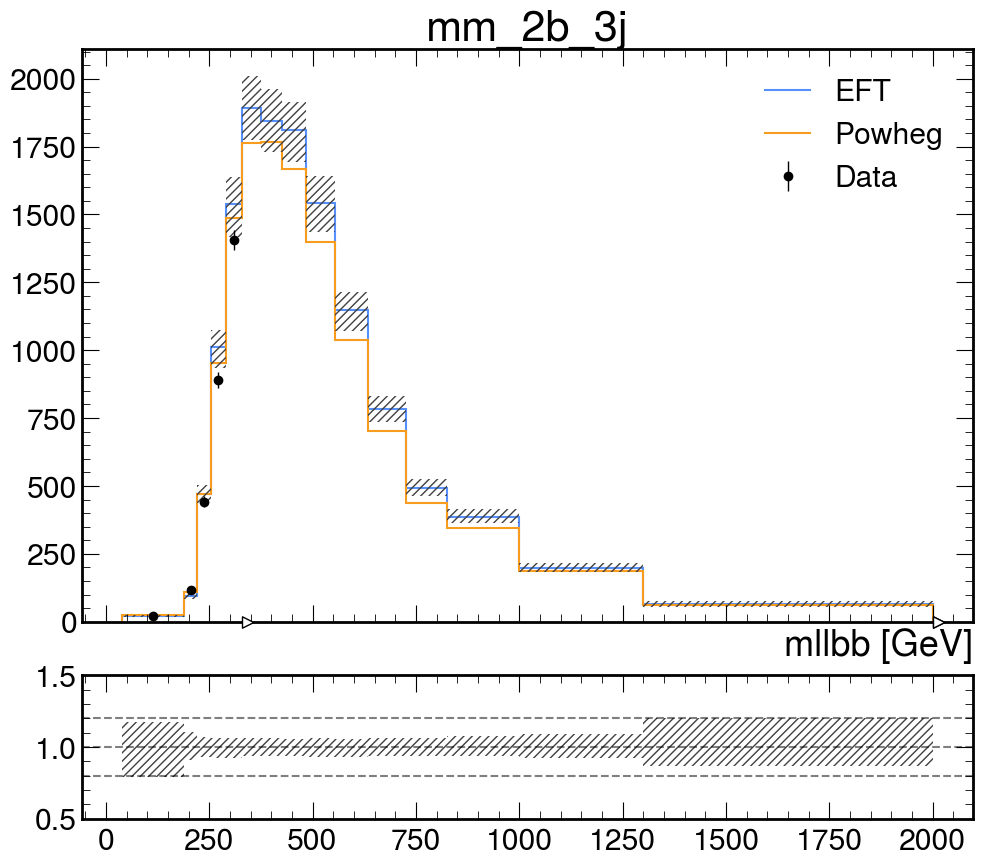

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


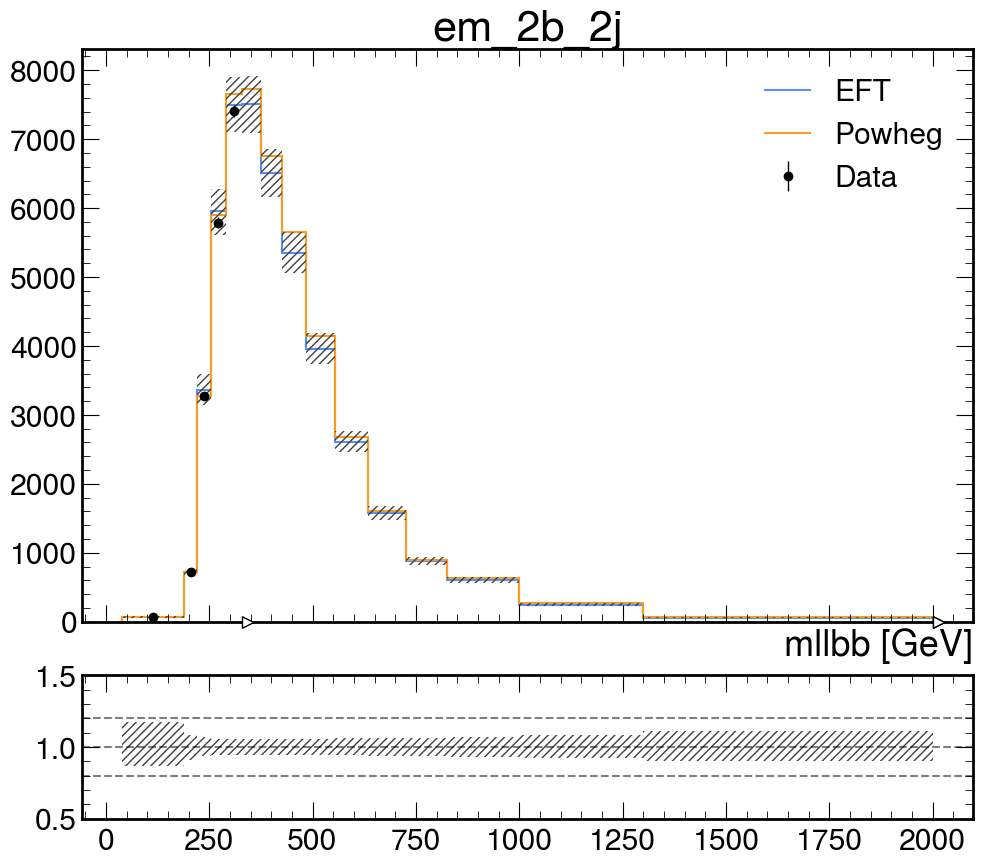

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


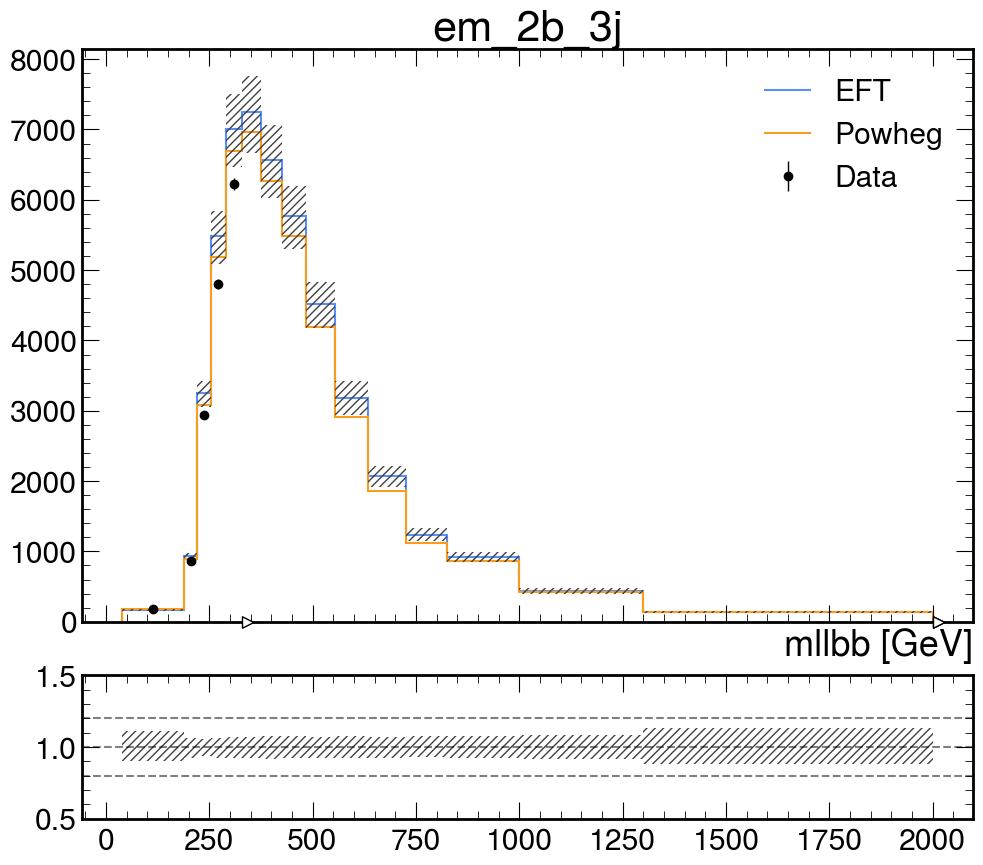

In [8]:
channel_conversion = {
    "ee_2b_2j":['ee_2b_2j'],
    "ee_2b_3j":['ee_2b_3j', 'ee_2b_4j'],
    "em_2b_2j":['em_2b_2j'],
    "em_2b_3j":['em_2b_3j', 'em_2b_4j'],
    "mm_2b_2j":['mm_2b_2j'],
    "mm_2b_3j":['mm_2b_3j', 'mm_2b_4j'],
}

var = 'mllbb'
for d in hists_EFT.keys():
    base_hist = hists_EFT[d][var]
    MC_procs = [x for x in list(base_hist.axes['process']) if 'data' not in x]
    data_procs = [x for x in list(base_hist.axes['process']) if 'data' in x]
    
    powheg_MC_procs = [x for x in list(hists_powheg[d][var].axes['process']) if 'data' not in x]
    channels = list(base_hist.axes['channel'])

    for ch in channels: 
        MC_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':MC_procs}][{'process':sum}].as_hist({})
        
        Powheg_hist = hists_powheg[d][var][{'systematic':'nominal', 'channel':channel_conversion[ch], 'process':powheg_MC_procs}][{'process':sum, 'channel':sum}].as_hist({})
        data_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':data_procs}][{'process':sum}].as_hist({})

        mc_err = base_hist[{'systematic':'sumw2', 'channel':ch, 'process':MC_procs}][{'process': sum}].as_hist({}).values()

        syst_to_apply = get_shape_syst_lst(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}))
        h_PDFweights = hists_EFT[d]['LHEPDFweights'][{'channel':ch}]
        shape_systs_summed_arr_m , shape_systs_summed_arr_p = get_shape_syst_arrs(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}), syst_var_lst=syst_to_apply, PDF_var_histo=h_PDFweights)

        nom_arr_all = MC_hist.values() 
        p_err_arr = nom_arr_all + np.sqrt(shape_systs_summed_arr_p + mc_err)
        m_err_arr = nom_arr_all - np.sqrt(shape_systs_summed_arr_m + mc_err)

        fig, (ax, rax) = plt.subplots(
            nrows=2,
            ncols=1,
            figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
            gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
            sharex=True
        )

        hep.style.use("CMS")

        hep.histplot(
            MC_hist,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"EFT",
            ax=ax
        )
        
        hep.histplot(
            Powheg_hist,
            stack=True,
            histtype="step",
            yerr=False,
            label=f"Powheg",
            ax=ax
        )

        ## Data Plot
        # ax.set_xlim([0, 350])
        hep.histplot(
            data_hist[0:5], 
            histtype='errorbar',
            markersize=12,
            yerr=True,
            color='black',
            label='Data',
            ax=ax
        )

        mc_vals = MC_hist.values()
        bin_edges = np.asarray(MC_hist.axes.edges[0])
        bin_centers = MC_hist.axes.centers

        ### add syst uncertainty band to main plot ###
        p_err_arr = np.where(mc_vals>0,p_err_arr,0)
        m_err_arr = np.where(mc_vals>0,m_err_arr,0)

        # print(f"p_err/nom: {p_err_arr/mc_vals}")
        # print(f"m_err/nom: {m_err_arr/mc_vals}")

        ax.fill_between(
            bin_edges, 
            np.append(m_err_arr, m_err_arr[-1]),
            np.append(p_err_arr, p_err_arr[-1]),
            # step='post', 
            # hatch='\\\\\\\\\\',
            # alpha=0.5,
            step='post', 
            hatch='////',
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        ### add syst uncertainty band to ratio plot ###
        p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
        m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

        rax.fill_between(
            bin_edges, 
            np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
            np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
            # step='post', 
            # hatch='\\\\\\\\\\',
            # # color='dimgrey',
            # alpha=0.1, 
            step='post', 
            hatch='////', # hatch='\\\\\\\\\\',
            # alpha=0.1, 
            edgecolor= '#404040',# 'dimgray',  
            facecolor='none',
            linewidth=0,
        )

        rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
        rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
        rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
        rax.set_yticks([0.5, 1.0, 1.5])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 

        ax.legend()
        ax.set_title(f"{ch}")
        plt.show()
        
        # save_figure(fig, f"mllbb_{ch}_EFT", "/users/hnelson2/ttbarEFT-coffea2025/analysis/unblind_plots_merge3j4j_0519/")
        # plt.close()

# all years, no year uncert

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.18822589 1.11273548 1.06043991 1.0639898  1.05882944 1.06031323
 1.0602441  1.06192738 1.06611213 1.06596319 1.07432413 1.08244511
 1.09789715 1.10757844 1.18043415]
m_err/nom: [0.84499574 0.89065583 0.92396954 0.9363958  0.93310069 0.94020038
 0.94152134 0.93934308 0.93610851 0.93573867 0.92914654 0.90985194
 0.9160539  0.89506638 0.83370092]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.15609344 1.07925012 1.05022999 1.0490847  1.04848321 1.05272575
 1.05516332 1.05873971 1.05417837 1.05822334 1.06031733 1.06769791
 1.06432297 1.08778792 1.17648503]
m_err/nom: [0.80704877 0.92913738 0.93611013 0.94538118 0.94971945 0.92730924
 0.93397534 0.93424281 0.94804833 0.92282741 0.92574995 0.94164437
 0.92433624 0.91491962 0.84167863]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.20394972 1.11705087 1.10164845 1.11539885 1.11312886 1.10850498
 1.12813617 1.11470954 1.11499382 1.10857263 1.11482899 1.11358543
 1.12322763 1.12934281 1.16215927]
m_err/nom: [0.7431016  0.89296772 0.8928446  0.88466656 0.89285758 0.8893856
 0.8862635  0.89773483 0.87475913 0.8817095  0.90016058 0.8974208
 0.87700072 0.87478484 0.83368673]


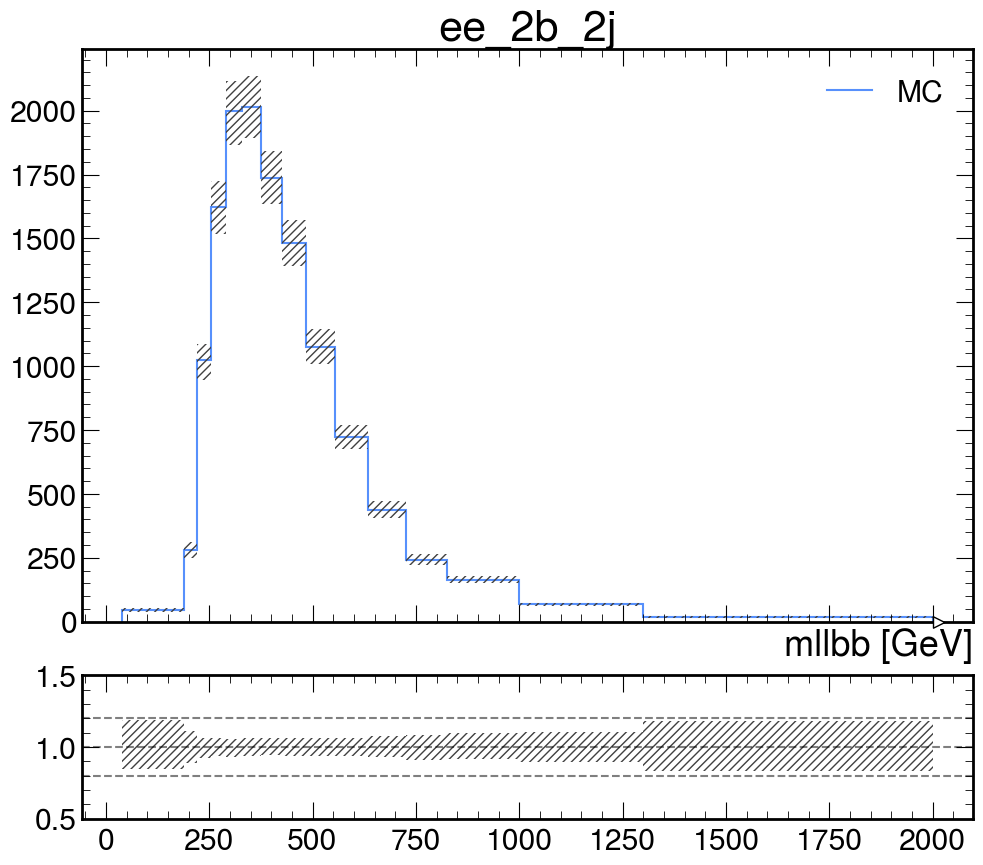

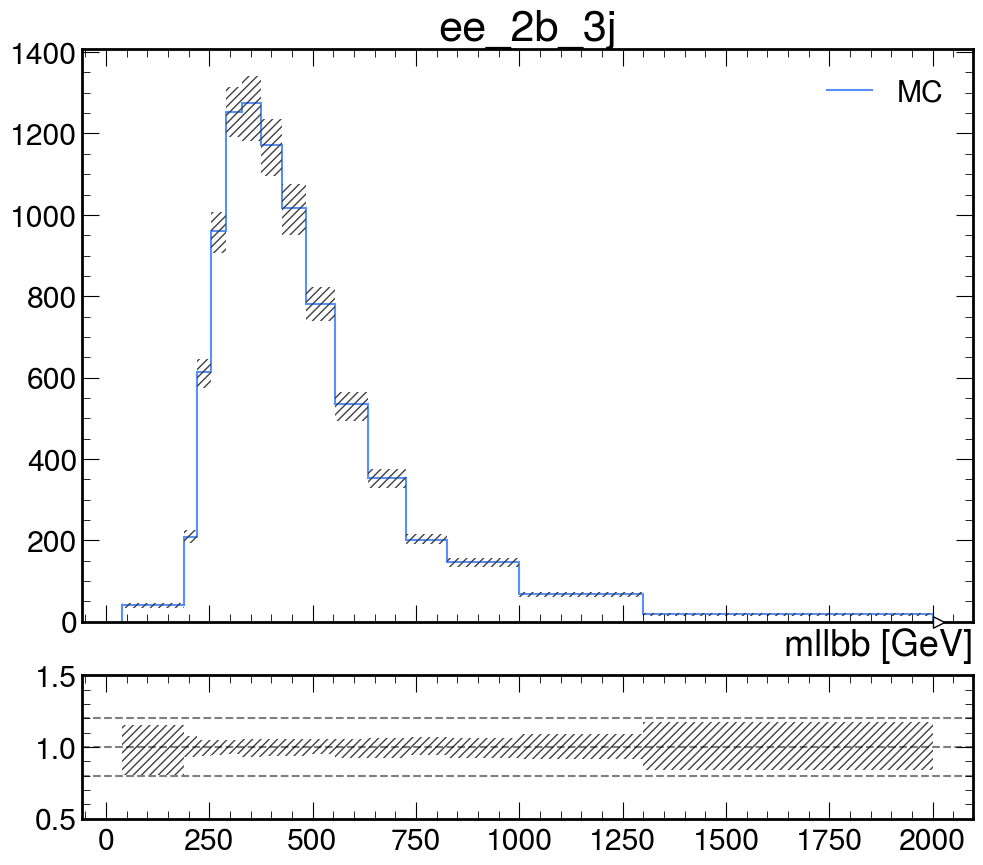

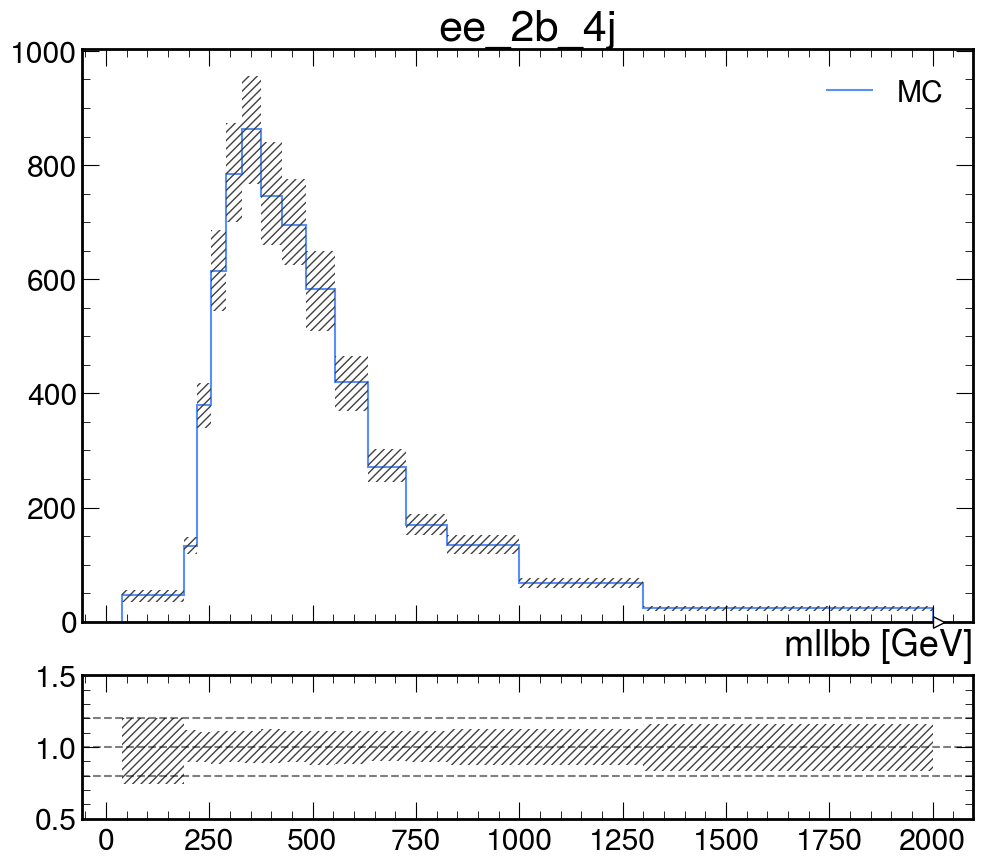

In [83]:
var = 'mllbb'
base_hist = hists_dict['ee'][var]
MC_procs = [x for x in list(base_hist.axes['process']) if 'data' not in x]
data_procs = [x for x in list(base_hist.axes['process']) if 'data' in x]
channels = list(base_hist.axes['channel'])

for ch in channels: 
    MC_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':MC_procs}][{'process':sum}].as_hist({})
    data_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':data_procs}][{'process':sum}].as_hist({})
    
    mc_err = base_hist[{'systematic':'sumw2', 'channel':ch, 'process':MC_procs}][{'process': sum}].as_hist({}).values()
    
    syst_to_apply = get_shape_syst_lst(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}))
    h_PDFweights = hists_dict['ee']['LHEPDFweights'][{'channel':ch}]
    shape_systs_summed_arr_m , shape_systs_summed_arr_p = get_shape_syst_arrs_noyears(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}), syst_var_lst=syst_to_apply, PDF_var_histo=h_PDFweights)
        
    nom_arr_all = MC_hist.values() 
    p_err_arr = nom_arr_all + np.sqrt(shape_systs_summed_arr_p + mc_err)
    m_err_arr = nom_arr_all - np.sqrt(shape_systs_summed_arr_m + mc_err)
    
    fig, (ax, rax) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
        gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
        sharex=True
    )

    hep.style.use("CMS")
    
    hep.histplot(
        MC_hist,
        stack=True,
        histtype="step",
        yerr=False,
        label=f"MC",
        ax=ax
    )
    
    ### Data Plot
#     ax.set_xlim([0, 350])
#     hep.histplot(
#         data_hist, 
#         histtype='errorbar',
#         markersize=12,
#         yerr=True,
#         color='black',
#         label='Data',
#         ax=ax
#     )
    
    mc_vals = MC_hist.values()
    bin_edges = np.asarray(MC_hist.axes.edges[0])
    bin_centers = MC_hist.axes.centers

    ### add syst uncertainty band to main plot ###
    p_err_arr = np.where(mc_vals>0,p_err_arr,0)
    m_err_arr = np.where(mc_vals>0,m_err_arr,0)
    
    print(f"p_err/nom: {p_err_arr/mc_vals}")
    print(f"m_err/nom: {m_err_arr/mc_vals}")
    
    ax.fill_between(
        bin_edges, 
        np.append(m_err_arr, m_err_arr[-1]),
        np.append(p_err_arr, p_err_arr[-1]),
        # step='post', 
        # hatch='\\\\\\\\\\',
        # alpha=0.5,
        step='post', 
        hatch='////',
        edgecolor= '#404040',# 'dimgray',  
        facecolor='none',
        linewidth=0,
    )
    
    ### add syst uncertainty band to ratio plot ###
    p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
    m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

    rax.fill_between(
        bin_edges, 
        np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
        np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
        # step='post', 
        # hatch='\\\\\\\\\\',
        # # color='dimgrey',
        # alpha=0.1, 
        step='post', 
        hatch='////', # hatch='\\\\\\\\\\',
        # alpha=0.1, 
        edgecolor= '#404040',# 'dimgray',  
        facecolor='none',
        linewidth=0,
    )
    
    rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
    rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
    rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
    rax.set_yticks([0.5, 1.0, 1.5])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 
    
    ax.legend()
    ax.set_title(f"{ch}")

# 2018 only, including year uncert

/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.26456846 1.11973129 1.07629774 1.07853308 1.06128401 1.06192873
 1.06076844 1.06482575 1.07201331 1.06642326 1.07749428 1.0833558
 1.1342011  1.11670175 1.18217681]
m_err/nom: [0.71290945 0.85284797 0.92314942 0.93178728 0.91892498 0.93983375
 0.93906369 0.93442532 0.92888972 0.93521892 0.92493168 0.9151137
 0.89422943 0.89994362 0.80285058]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.31431657 1.09242447 1.06030735 1.05844772 1.05680952 1.06172082
 1.06241762 1.06498646 1.0593372  1.07625709 1.06495854 1.07740688
 1.06871252 1.11307387 1.22613786]
m_err/nom: [0.7060545  0.91761694 0.92313792 0.92879449 0.9521462  0.9217938
 0.92283754 0.93401038 0.951866   0.91361224 0.91343722 0.94044036
 0.92293475 0.87887842 0.8146971 ]


/users/hnelson2/micromamba/envs/coffea2025/lib/python3.13/site-packages/hist/basehist.py:499: UserWarning: List indexing selection is experimental. Removed bins are not placed in overflow.
  return super().__getitem__(self._index_transform(index))


p_err/nom: [1.36648502 1.13377345 1.10421907 1.12317113 1.10906988 1.10667179
 1.14404256 1.12000494 1.12099012 1.09651519 1.12156975 1.1372246
 1.11386959 1.16935688 1.18299985]
m_err/nom: [0.47736136 0.8903766  0.88963538 0.86638919 0.89108188 0.86013353
 0.88805752 0.89235586 0.88552669 0.86882862 0.90968781 0.85477163
 0.81397415 0.85773107 0.84945768]


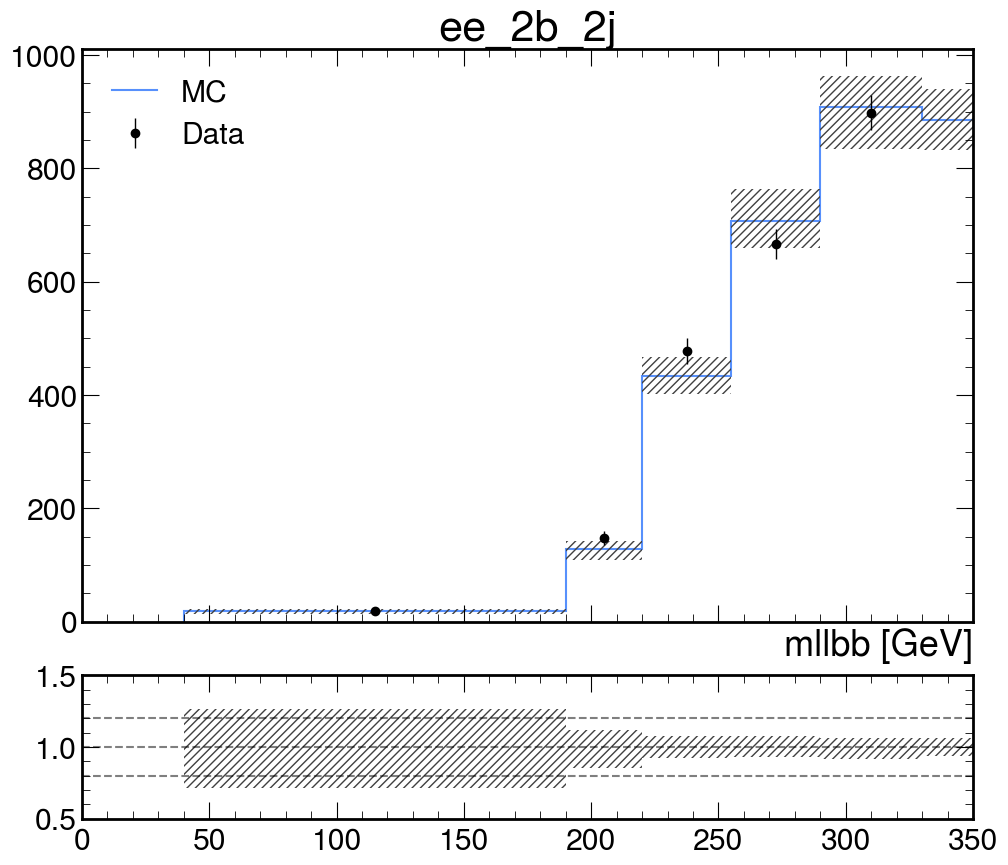

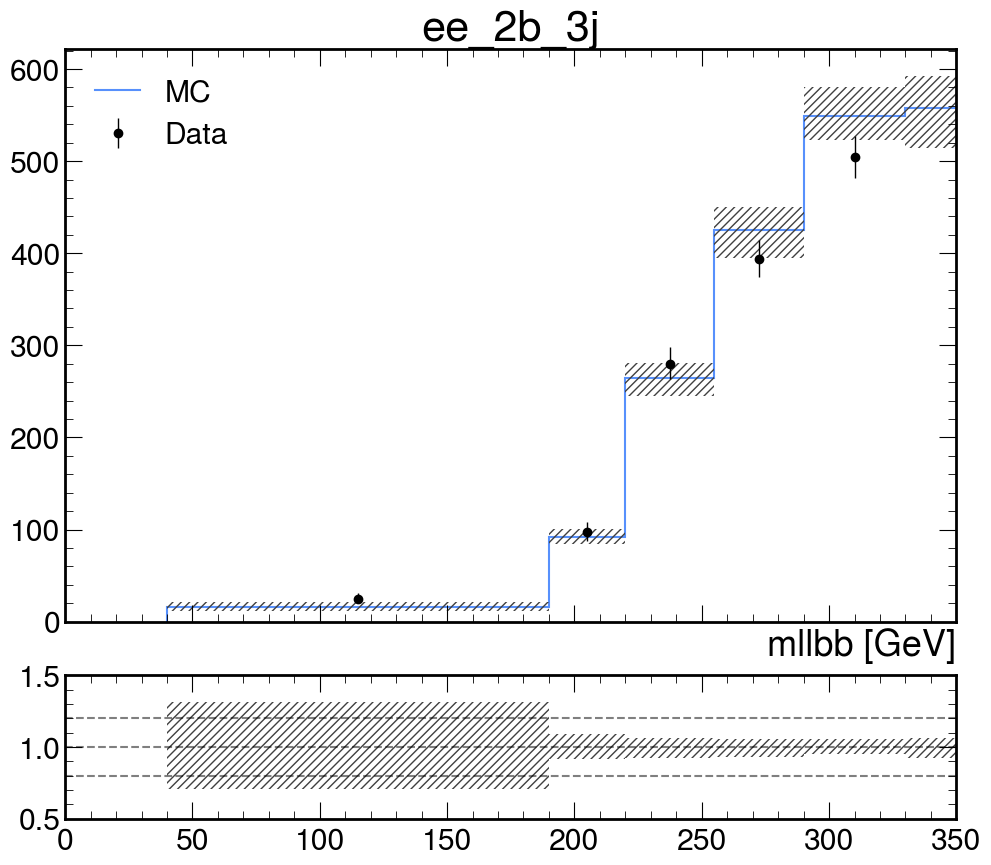

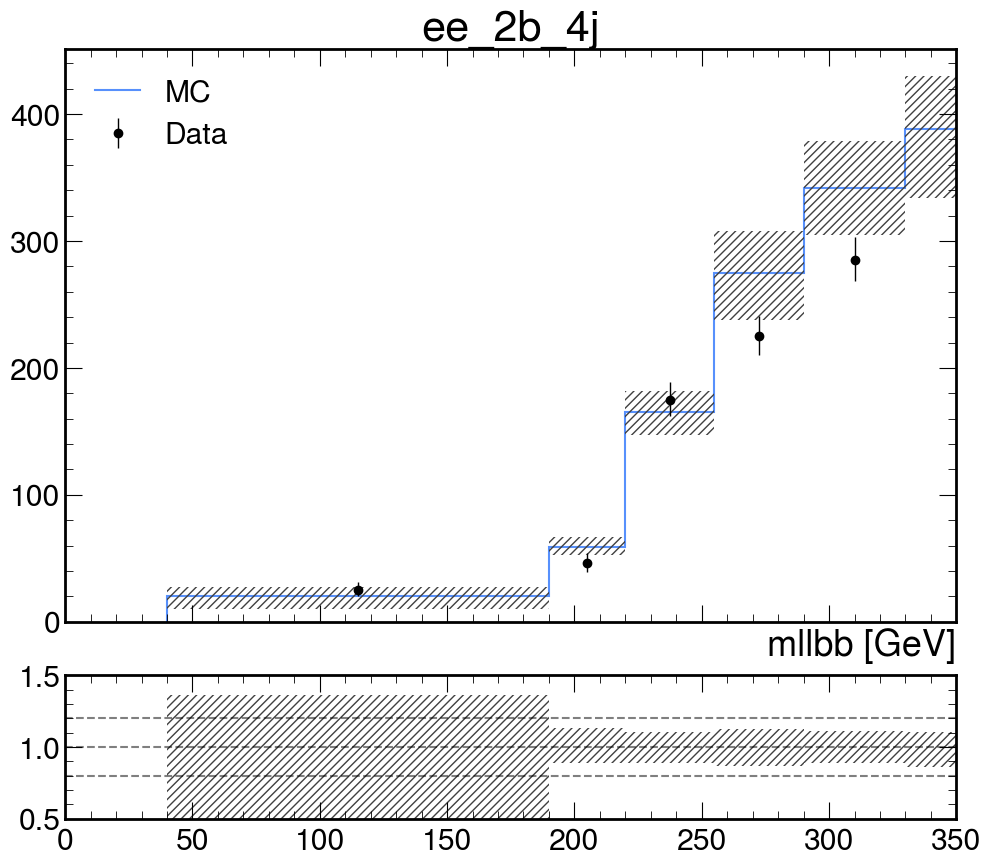

In [81]:
var = 'mllbb'
base_hist = hists_dict['ee'][var]
procs_2018 = [x for x in list(base_hist.axes['process']) if x.endswith('18')]

MC_procs = [x for x in procs_2018 if 'data' not in x]
data_procs = [x for x in procs_2018 if 'data' in x]
channels = list(base_hist.axes['channel'])

for ch in channels: 
    MC_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':MC_procs}][{'process':sum}].as_hist({})
    data_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':data_procs}][{'process':sum}].as_hist({})
    
    mc_err = base_hist[{'systematic':'sumw2', 'channel':ch, 'process':MC_procs}][{'process': sum}].as_hist({}).values()
    
    syst_to_apply = get_shape_syst_lst(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}))
    h_PDFweights = hists_dict['ee']['LHEPDFweights'][{'channel':ch}]
    shape_systs_summed_arr_m , shape_systs_summed_arr_p = get_shape_syst_arrs(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}), syst_var_lst=syst_to_apply, PDF_var_histo=h_PDFweights)
        
    nom_arr_all = MC_hist.values() 
    p_err_arr = nom_arr_all + np.sqrt(shape_systs_summed_arr_p + mc_err)
    m_err_arr = nom_arr_all - np.sqrt(shape_systs_summed_arr_m + mc_err)
    
    fig, (ax, rax) = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(11.5,10),                                        # figsize=(10,12), # figsize=(11.5,10), figsize =(10, 10)
        gridspec_kw={'height_ratios': (4, 1), 'hspace':0.15},     # gridspec_kw={'height_ratios': (3, 1), 'hspace':0.05},
        sharex=True
    )

    hep.style.use("CMS")
    
    hep.histplot(
        MC_hist,
        stack=True,
        histtype="step",
        yerr=False,
        label=f"MC",
        ax=ax
    )
    
    ## Data Plot
    ax.set_xlim([0, 350])
    hep.histplot(
        data_hist, 
        histtype='errorbar',
        markersize=12,
        yerr=True,
        color='black',
        label='Data',
        ax=ax
    )
    
    mc_vals = MC_hist.values()
    bin_edges = np.asarray(MC_hist.axes.edges[0])
    bin_centers = MC_hist.axes.centers

    ### add syst uncertainty band to main plot ###
    p_err_arr = np.where(mc_vals>0,p_err_arr,0)
    m_err_arr = np.where(mc_vals>0,m_err_arr,0)
    
    print(f"p_err/nom: {p_err_arr/mc_vals}")
    print(f"m_err/nom: {m_err_arr/mc_vals}")
    
    ax.fill_between(
        bin_edges, 
        np.append(m_err_arr, m_err_arr[-1]),
        np.append(p_err_arr, p_err_arr[-1]),
        # step='post', 
        # hatch='\\\\\\\\\\',
        # alpha=0.5,
        step='post', 
        hatch='////',
        edgecolor= '#404040',# 'dimgray',  
        facecolor='none',
        linewidth=0,
    )
    
    ### add syst uncertainty band to ratio plot ###
    p_err_arr_ratio = np.where(mc_vals>0,p_err_arr/mc_vals,1)
    m_err_arr_ratio = np.where(mc_vals>0,m_err_arr/mc_vals,1)

    rax.fill_between(
        bin_edges, 
        np.append(m_err_arr_ratio, m_err_arr_ratio[-1]), 
        np.append(p_err_arr_ratio, p_err_arr_ratio[-1]), 
        # step='post', 
        # hatch='\\\\\\\\\\',
        # # color='dimgrey',
        # alpha=0.1, 
        step='post', 
        hatch='////', # hatch='\\\\\\\\\\',
        # alpha=0.1, 
        edgecolor= '#404040',# 'dimgray',  
        facecolor='none',
        linewidth=0,
    )
    
    rax.axhline(y=1.0, color='black', linestyle='--', alpha=0.5)
    rax.axhline(y=0.8, color='black', linestyle='--', alpha=0.5)
    rax.axhline(y=1.2, color='black', linestyle='--', alpha=0.5)
    rax.set_ylim([0.5, 1.5])                    # rax.set_ylim([0.5, 1.5])
    rax.set_yticks([0.5, 1.0, 1.5])             # rax.set_yticks([0.8, 1.0, 1.2, 1.4]) 
    
    ax.legend()
    ax.set_title(f"{ch}")

# Individually Checking what's going on 

In [59]:
var = 'mllbb'
base_hist = hists_dict['ee'][var]
MC_procs = [x for x in list(base_hist.axes['process']) if 'data' not in x]
data_procs = [x for x in list(base_hist.axes['process']) if 'data' in x]
channels = list(base_hist.axes['channel'])
ch = 'ee_2b_2j'

In [ ]:
MC_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':MC_procs}][{'process':sum}].as_hist({})
data_hist = base_hist[{'systematic':'nominal', 'channel':ch, 'process':data_procs}][{'process':sum}].as_hist({})
mc_err = base_hist[{'systematic':'sumw2', 'channel':ch, 'process':MC_procs}][{'process': sum}].as_hist({}).values()

syst_to_apply = get_shape_syst_lst(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}))
systs_to_apply = ['elecHEEP', 'FSR', 'JER_2017', 'btagSFbc_2016APV']
# h_PDFweights = hists_dict['ee']['LHEPDFweights'][{'channel':ch}]
# shape_systs_summed_arr_m , shape_systs_summed_arr_p = get_shape_syst_arrs_noyears(base_hist[{'channel':ch, 'process':MC_procs}].as_hist({}), syst_var_lst=syst_to_apply, PDF_var_histo=h_PDFweights)

# nom_arr_all = MC_hist.values() 
# p_err_arr = nom_arr_all + np.sqrt(shape_systs_summed_arr_p + mc_err)
# m_err_arr = nom_arr_all - np.sqrt(shape_systs_summed_arr_m + mc_err)

In [ ]:
p_arr_rel_lst = []
m_arr_rel_lst = []

syst_var_lst = systs_to_apply
base_histo = base_hist[{'channel':ch, 'process':MC_procs}].as_hist({})

for syst_name in syst_var_lst:
    print(f"syst: {syst_name}")
    syst_year_suffix = None
    target_process_year = None
    for yr_syst, yr_proc in year_naming.items():
        if yr_syst in syst_name:
            syst_year_suffix = yr_syst
            target_process_year = yr_proc
            break
    
    print(syst_year_suffix)
    print(target_process_year)
    
    h_up = base_histo[{"systematic": syst_name + "Up"}]
    all_relevant_samples = list(h_up.axes["process"])
    
    if syst_year_suffix:
        # Separate samples: those matching the systematic's year vs all other years
        var_samples = [s for s in all_relevant_samples if target_process_year in s]
        nom_samples = [s for s in all_relevant_samples if target_process_year not in s]
        
        print(var_samples)
        print(nom_samples)

syst: elecHEEP
None
None
syst: FSR
None
None
syst: JER_2017
2017
UL17
['TT01j2lmtt0to700_UL17', 'TT01j2lmtt700to900_UL17', 'TT01j2lmtt900toInf_UL17', 'TW_NoFullyHadronicDecays_centralUL17', 'DY10to50_centralUL17', 'DY50_centralUL17', 'TTGJets_centralUL17', 'ttW_centralUL17', 'ttZ_centralUL17', 'WJetsToLNu_centralUL17', 'WWTo2L2Nu_centralUL17', 'WZTo3LNu_centralUL17', 'ZZTo4L_centralUL17']
['TT01j2lmtt0to700_UL16APV', 'TT01j2lmtt700to900_UL16APV', 'TT01j2lmtt900toInf_UL16APV', 'TT01j2lmtt0to700_UL16', 'TT01j2lmtt700to900_UL16', 'TT01j2lmtt900toInf_UL16', 'TT01j2lmtt0to700_UL18', 'TT01j2lmtt700to900_UL18', 'TT01j2lmtt900toInf_UL18', 'TW_NoFullyHadronicDecays_centralUL16APV', 'DY10to50_centralUL16APV', 'DY50_centralUL16APV', 'TTGJets_centralUL16APV', 'ttW_centralUL16APV', 'ttZ_centralUL16APV', 'WJetsToLNu_centralUL16APV', 'WWTo2L2Nu_centralUL16APV', 'WZTo3LNu_centralUL16APV', 'ZZTo4L_centralUL16APV', 'TW_NoFullyHadronicDecays_centralUL16', 'DY10to50_centralUL16', 'DY50_centralUL16', 'TTGJ